In [83]:
EMA_path = "./../inference/combined/EMA.json"
JAPAN_path = "./../inference/combined/JAPAN.json"
SWISSMEDIC_path = "./../inference/combined/SWISSMEDIC.json"
# AUSTRALIA_path = "./../inference/combined/AUSTRALIA.json"

SAVE_DIR = "./../inference/combined/figures/"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

In [ ]:
def load_data(file_path):
    """Load data from a JSON file."""
    with open(file_path, 'r') as file:
        data = json.load(file)
    return pd.DataFrame(data)

def to_lower(df):
    return df.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

def remove_invalid_rows(df):
    invalid_rows = df.apply(lambda x: x.astype(str).str.contains("the response is not valid json", case=False, na=False))
    print(f"Total rows with invalid responses: {invalid_rows.any(axis=1).sum()}")
    df = df[~invalid_rows.any(axis=1)]
    return df

def prepare_for_analysis(filepath):
    df = load_data(filepath)
    df = df.transpose()
    df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)
    df = remove_invalid_rows(df)
    df = to_lower(df)
    return df

def date_to_int(df, col_name):
    df = df.copy()
    original_len = len(df)
    df[col_name] = pd.to_datetime(df[col_name], errors='coerce')
    df[col_name] = df[col_name].dt.year
    df = df.dropna(subset=[col_name]).astype({col_name: 'int'})
    final_len = len(df)
    print(f"Original length: {original_len}, Final length after cleaning: {final_len}, Percentage kept: {final_len/original_len*100:.2f}%")
    return df

def plot_timeline(df, col_name, dataset_name=None):
    df = date_to_int(df, col_name)  # Ensure column is integer (e.g., year)
    unique_vals = sorted(df[col_name].unique())
    bins = np.append(unique_vals, unique_vals[-1] + 1)
    plt.figure(figsize=(8, 4))
    ax = plt.gca()
    counts, edges, patches = plt.hist(df[col_name], bins=bins, color="seagreen", edgecolor='black', align='left', alpha=0.7)
    ax.set_xticks(unique_vals)
    ax.set_xticklabels([str(int(x)) for x in unique_vals], rotation=45, ha='center')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_{col_name}_timeline.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_distribution(df, drug_class_colormap=None, dataset_name=None):
    class_order = df['Drug_class'].value_counts().index
    palette = {cls: drug_class_colormap[cls] for cls in class_order}
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')
    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 0.5,
            s=int(height),
            ha='center', va='bottom', fontsize=9
        )
    plt.xticks(rotation=45, ha='right')
    # plt.title('Distribution of Drug Classes')
    plt.xlabel('Drug Class')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_distribution_pie(df, drug_class_colormap=None, dataset_name=None):
    class_counts = df['Drug_class'].value_counts()
    cmap = plt.get_cmap('tab20')
    labels = class_counts.index
    sizes = class_counts.values
    colors = [drug_class_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(5, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )
    legend_labels = [f"{label} ({size / total * 100:.1f}%)" for label, size in zip(labels, sizes)]

    plt.legend(
        wedges,
        legend_labels,
        title='Drug Class',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    # plt.title('Distribution of Drug Classes')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_distribution_pie.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_drug_class_per_year(df, col_name, drug_class_colormap=None, dataset_name=None):
    df = date_to_int(df, col_name)
    print(df[col_name].value_counts().sort_index())

    # Count number of drugs per class per year
    class_counts = df.groupby([col_name, 'Drug_class']).size().unstack(fill_value=0)

    # Optional: order columns by total size across all years
    class_counts = class_counts[class_counts.sum().sort_values(ascending=False).index]

    # Create color list using consistent colormap
    colors = [drug_class_colormap[cls] for cls in class_counts.columns]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    class_counts.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black')

    ax.set_xlabel(col_name)
    ax.set_ylabel('Number of Drugs')
    ax.set_title('Drug Class Distribution Over Years')
    ax.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}{dataset_name}_drug_class_per_year.png", dpi=300, bbox_inches='tight')

    plt.show()



In [86]:
EMA = prepare_for_analysis(EMA_path)
JAPAN = prepare_for_analysis(JAPAN_path)
SWISSMEDIC = prepare_for_analysis(SWISSMEDIC_path)

Total rows with invalid responses: 6
Total rows with invalid responses: 0
Total rows with invalid responses: 0


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_10404\782730176.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)


In [87]:
all_classes = pd.concat([EMA['Drug_class'], JAPAN['Drug_class'], SWISSMEDIC['Drug_class']]).unique()
print("All unique drug classes across datasets:", all_classes)
cmap = plt.get_cmap('tab20')
colors = cmap(np.linspace(0, 1, len(all_classes)))
drug_class_colormap = dict(zip(all_classes, colors))

All unique drug classes across datasets: ['small molecule' 'biologics' 'peptides and proteins' 'other' 'vaccine'
 'cell and gene therapy' 'vitamins' 'antibiotic' 'antibiotics'
 'antibody-drug conjugate' 'gene therapy' 'antisense oligonucleotide'
 'oligonucleotide']


In [88]:
EMA.columns

Index(['Marketing_authorisation_number', 'Procedure_number', 'Drug_name',
       'Non_proprietary_name', 'Marketing_authorisation_holder', 'Drug_class',
       'Pharmaceutical_form', 'Administration_route', 'Decision',
       'Current_status', 'Decision_date', 'Decision_year',
       'Orphan_drug_status', 'Indication_extended', 'Indication_requested',
       'Indication_approved', 'Disease_class(es)', 'Application_date',
       'Application_year', 'Nonclinical_abridged', 'Referral_body',
       'Document_name'],
      dtype='object')

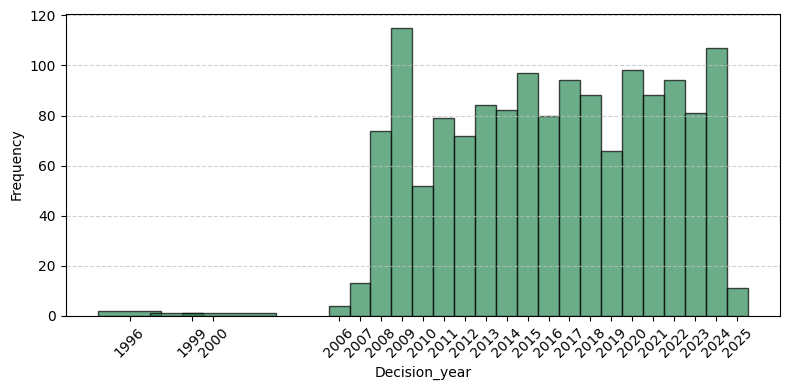

TypeError: can only concatenate str (not "int") to str

In [90]:
plot_timeline(EMA, col_name='Decision_year', dataset_name='EMA')
plot_timeline(JAPAN, col_name='Decision_year', dataset_name='JAPAN')
plot_timeline(SWISSMEDIC, col_name='Decision_year', dataset_name='SWISSMEDIC')

In [ ]:
print(EMA["Application_year"].unique())

[2023 2021 2022 2010 2014 2017 2008 2011 2007 2009 2013 2019 2018 2020
 2015 2012 2016 2006 2005 2024 2004 1999 1995 2003 2001 2000 1998]


Original length: 1491, Final length after cleaning: 1491, Percentage kept: 100.00%


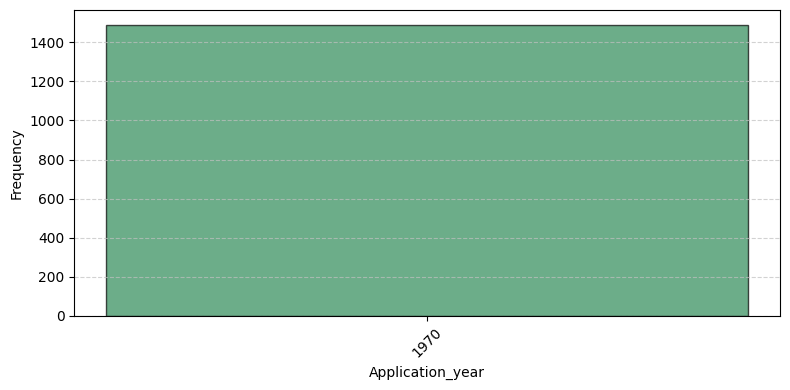

Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


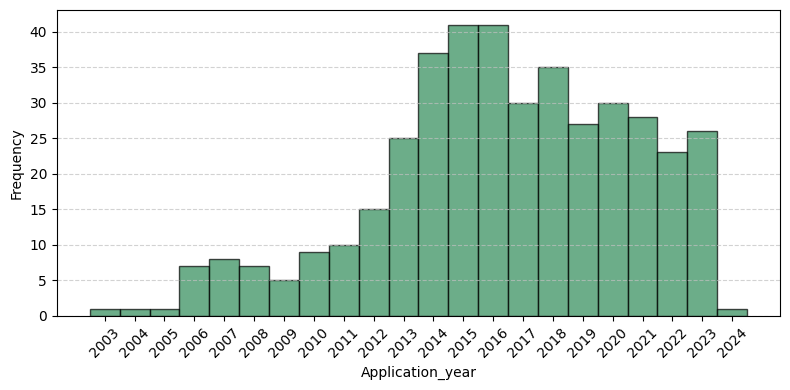

Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


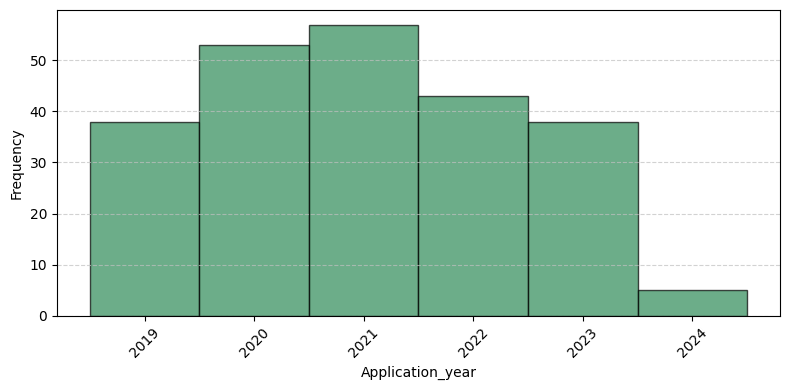

In [ ]:
plot_timeline(EMA, col_name='Application_year', dataset_name='EMA')
plot_timeline(JAPAN, col_name='Application_year', dataset_name='JAPAN')
plot_timeline(SWISSMEDIC, col_name='Application_year', dataset_name='SWISSMEDIC')

In [ ]:
print(EMA["Application_year"].unique())

[1970]


In [ ]:
EMA["Drug_class"].unique()

array(['peptides and proteins', 'other', 'biologics', 'small molecule',
       'vaccine', 'cell and gene therapy', 'vitamins', 'antibiotic',
       'antibiotics', 'antibody-drug conjugate', 'gene therapy',
       'antisense oligonucleotide', 'oligonucleotide'], dtype=object)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_10404\1474167408.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


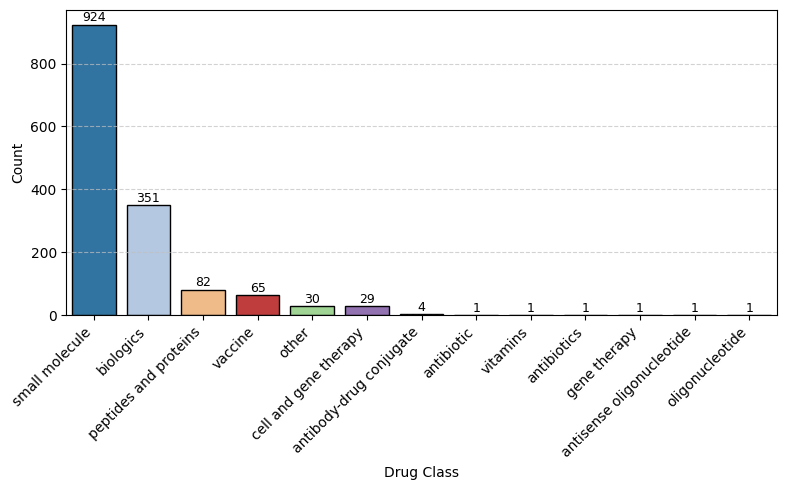

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_10404\1474167408.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


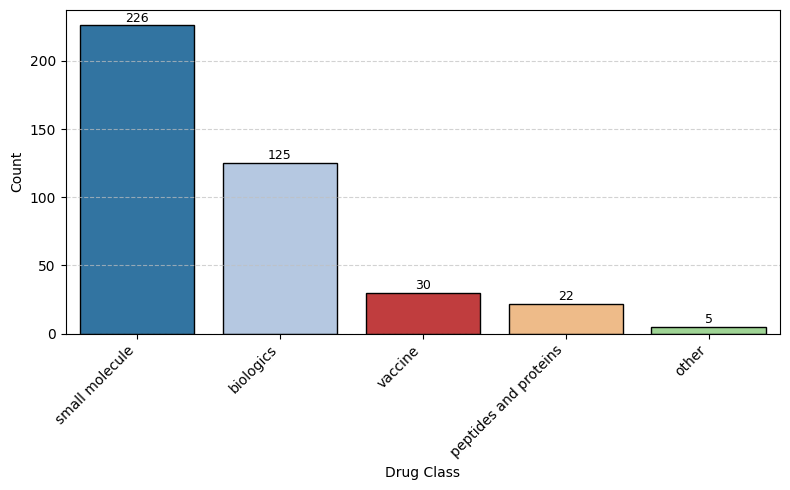

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_10404\1474167408.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Drug_class', order=df['Drug_class'].value_counts().index, palette=palette, edgecolor='black')


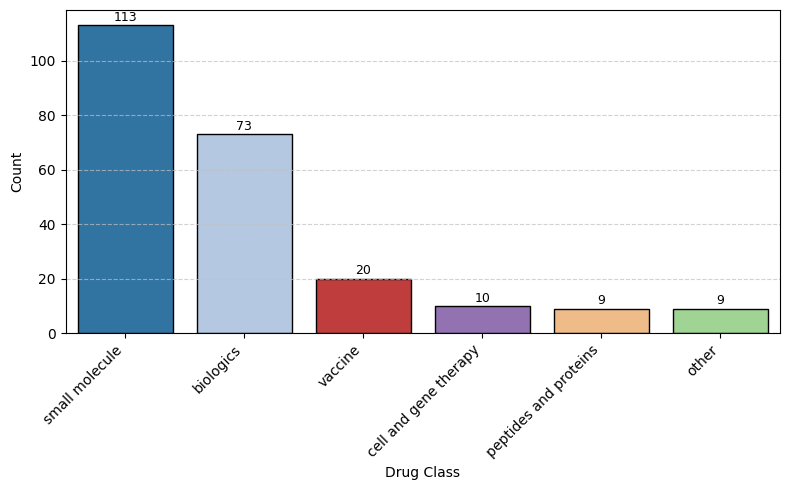

In [ ]:
plot_drug_class_distribution(EMA, drug_class_colormap, dataset_name='EMA')
plot_drug_class_distribution(JAPAN, drug_class_colormap, dataset_name='JAPAN')
plot_drug_class_distribution(SWISSMEDIC, drug_class_colormap, dataset_name='SWISSMEDIC')

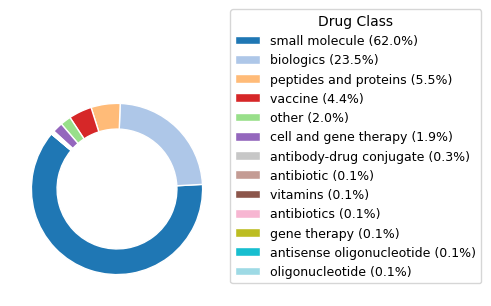

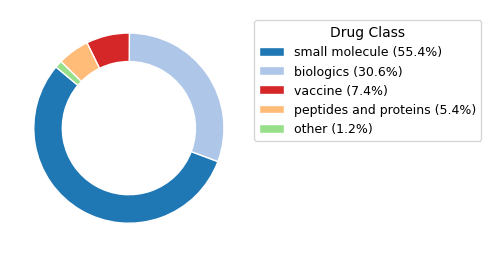

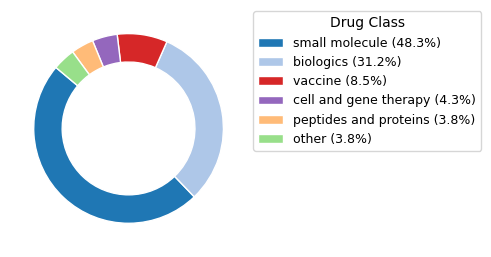

In [ ]:
plot_drug_class_distribution_pie(EMA, drug_class_colormap, dataset_name='EMA')
plot_drug_class_distribution_pie(JAPAN, drug_class_colormap, dataset_name='JAPAN')
plot_drug_class_distribution_pie(SWISSMEDIC, drug_class_colormap, dataset_name='SWISSMEDIC')

In [ ]:
print(EMA["Application_year"].unique())

[1970]


Original length: 1491, Final length after cleaning: 1491, Percentage kept: 100.00%
Application_year
1970    1491
Name: count, dtype: int64


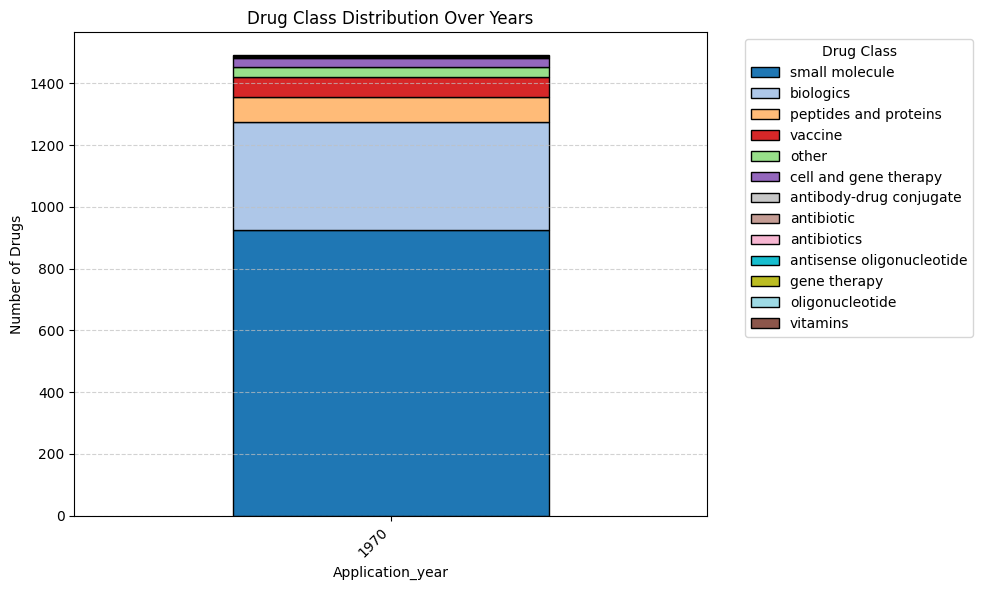

Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%
Application_year
1970    408
Name: count, dtype: int64


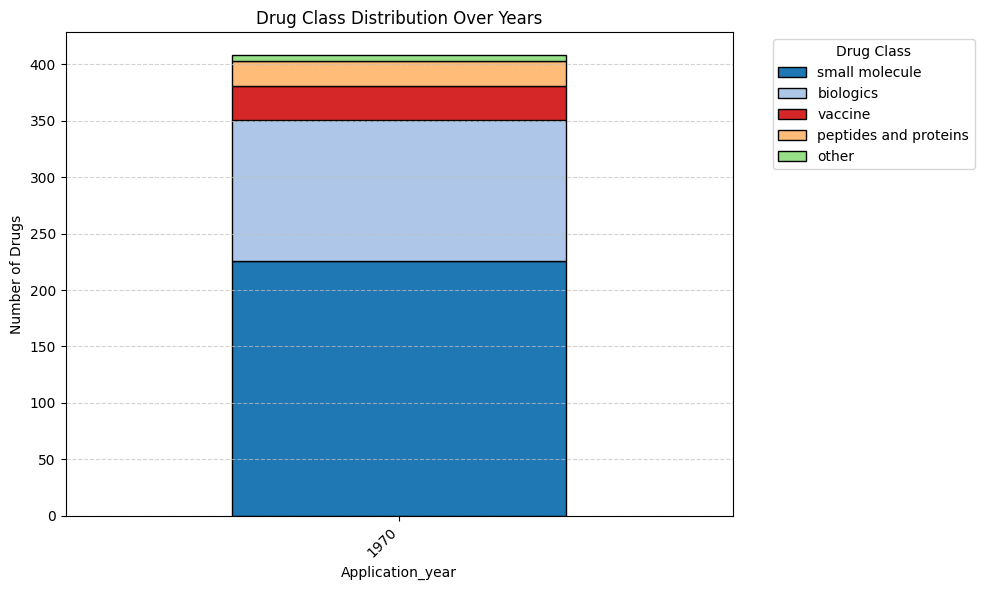

Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%
Application_year
1970    234
Name: count, dtype: int64


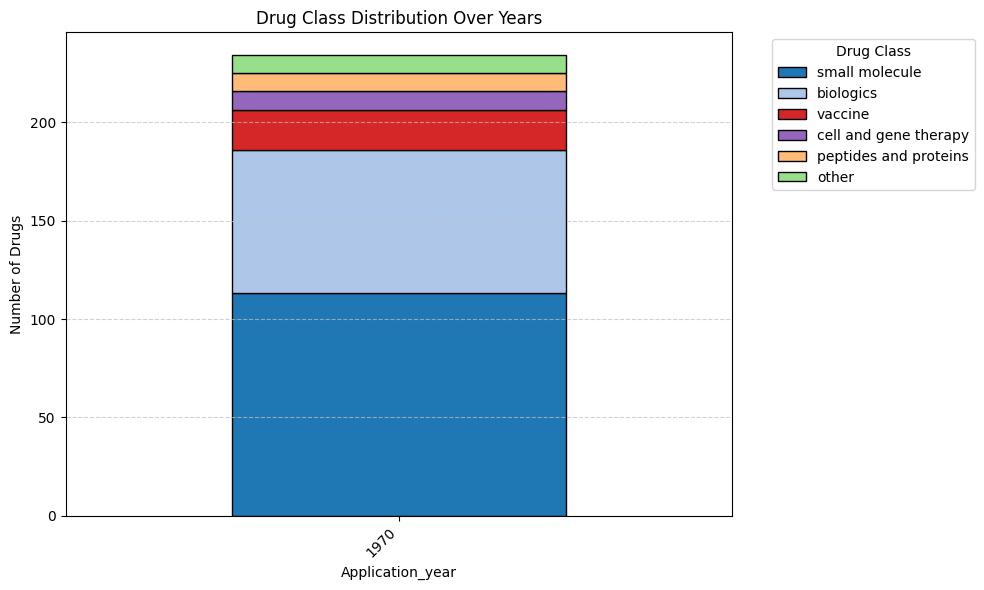

In [ ]:
plot_drug_class_per_year(EMA, "Application_year", drug_class_colormap, "EMA")
plot_drug_class_per_year(JAPAN, "Application_year", drug_class_colormap, "JAPAN")
plot_drug_class_per_year(SWISSMEDIC, "Application_year", drug_class_colormap, "SWISSMEDIC")